# Conditional horizontal divergence at selected depths


In [21]:
from pathlib import Path
import sys
import importlib
import json
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in (PROJECT_DIR, FLOW_SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
case_name = "run_aug1_v18"
RUN_TITLE_INFO = "Case AUG-1-v18"

V18 = np.array([
    *([12.5] * 4),
    13.750,
    19.352, 27.235, 38.330, 53.946,
    75.923, 106.852, 150.383, 211.647,
    297.869, 419.217, 590.001, 830.359,
    1168.636
], dtype=float)

STATE_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
SPINUP_FILE = STATE_FILE.with_name(f"{STATE_FILE.stem}_spinup{STATE_FILE.suffix}")

OUT_DIR = (NB_DIR / f"../results/{case_name}").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE = True
DX = 500.0
DY = 500.0
F0 = 8.0e-5

# Labels shown in the figure. The state file provides the nearest stored
# records to 7 and 13 days after the spin-up snapshot.
PLOT_DAYS = [0.0, 7.0, 13.0]
STATE_TARGET_DAYS = [7.0, 13.0]

# Keep the near-surface layer exactly as before.
NEAR_SURFACE_UV_INDEX = 1
TARGET_DEPTHS_M = [50.0, 1000.0]
NEAR_SURFACE_W_INDEX = 1

NBINS = 90
MIN_BIN_COUNT = 1
PERCENTILE_LIMIT = 98
W_TO_M_PER_DAY = True

DELR = V18

UV_DEPTHS_M = np.cumsum(DELR) - 0.5 * DELR
W_DEPTHS_M = np.concatenate(([0.0], np.cumsum(DELR)))

plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.titlesize": 27,
})

for path in (STATE_FILE, SPINUP_FILE):
    if not path.exists():
        raise FileNotFoundError(path)


print(f"State file  : {STATE_FILE}")
print(f"Spin-up file: {SPINUP_FILE}")

State file  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_v18.nc
Spin-up file: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_v18_spinup.nc


In [22]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def open_case(path):
    ds = xr.open_dataset(path, chunks="auto")
    time_dim = shu.find_dim(ds.dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    w_dim = (
        shu.find_dim(ds["WVEL"].dims, ["Zl", "Z", "Zmd", "k", "depth"])
        if "WVEL" in ds else None
    )
    return ds, time_dim, z_dim, w_dim


def time_seconds(ds, time_dim):
    values = np.asarray(ds[time_dim].values)
    units = str(ds[time_dim].attrs.get("units", "")).lower()

    if np.issubdtype(values.dtype, np.datetime64):
        return np.asarray((values - values[0]) / np.timedelta64(1, "s"), dtype=float)
    if np.issubdtype(values.dtype, np.timedelta64):
        return np.asarray(values / np.timedelta64(1, "s"), dtype=float)

    values = values.astype(float)
    if "day" in units:
        return values * 86400.0
    if "hour" in units:
        return values * 3600.0
    return values  # MITgcm numeric clock used here is in seconds


def uv_depths_for(ds, z_dim):
    n = ds.sizes[z_dim]
    if n > UV_DEPTHS_M.size:
        raise ValueError("U/V dataset has more vertical levels than DELR defines.")
    return UV_DEPTHS_M[:n]



def nearest_index(depths, target, min_index=0):
    return int(np.argmin(np.abs(depths[min_index:] - target)) + min_index)


def select_uv_indices(depths):
    if len(TARGET_DEPTHS_M) != 2:
        raise ValueError("TARGET_DEPTHS_M must contain exactly two depths.")

    return [
        NEAR_SURFACE_UV_INDEX,
        nearest_index(depths, TARGET_DEPTHS_M[0], NEAR_SURFACE_UV_INDEX),
        nearest_index(depths, TARGET_DEPTHS_M[1], NEAR_SURFACE_UV_INDEX),
    ]


def usable_uv_record(ds, time_dim, z_dim, it, uv_indices):
    """
    Check whether UVEL and VVEL contain usable data at all selected levels.

    UVEL and VVEL are checked separately because MITgcm stores them on
    different staggered C-grid faces, so their native shapes need not match.
    """
    for k in uv_indices:
        u = shu.clean_fill(
            ds["UVEL"].isel({time_dim: it, z_dim: k}).values
        )
        v = shu.clean_fill(
            ds["VVEL"].isel({time_dim: it, z_dim: k}).values
        )

        valid_u = np.isfinite(u)
        valid_v = np.isfinite(v)

        # Reject empty or almost completely missing records.
        if valid_u.mean() < 0.1 or valid_v.mean() < 0.1:
            return False

        if not valid_u.any() or not valid_v.any():
            return False

        u_std = np.nanstd(u[valid_u])
        v_std = np.nanstd(v[valid_v])

        # Reject unfilled records represented by constant zeros.
        if (
            not np.isfinite(u_std)
            or not np.isfinite(v_std)
            or (u_std <= 1.0e-14 and v_std <= 1.0e-14)
        ):
            return False

    return True


def select_spinup_record(ds, time_dim, z_dim, uv_indices):
    valid = [
        it for it in range(ds.sizes[time_dim])
        if usable_uv_record(ds, time_dim, z_dim, it, uv_indices)
    ]
    if not valid:
        raise ValueError("The spin-up file contains no usable U/V record.")
    return valid[-1]  # spin-up-end snapshot


def select_state_record(ds, time_dim, z_dim, uv_indices, start_time_s, target_day):
    times_s = time_seconds(ds, time_dim)
    valid = np.array([
        it for it in range(ds.sizes[time_dim])
        if usable_uv_record(ds, time_dim, z_dim, it, uv_indices)
    ], dtype=int)
    if valid.size == 0:
        raise ValueError("The state file contains no usable U/V records.")

    elapsed_days = (times_s[valid] - start_time_s) / 86400.0
    position = int(np.argmin(np.abs(elapsed_days - target_day)))
    it = int(valid[position])
    return it, float(elapsed_days[position]), float(times_s[it])


def compute_kinematics(ds, time_dim, z_dim, it, kuv):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)
        ro, div_f, strain = shu.compute_surface_kinematics(
            ds, time_dim, z_dim, it, [kuv], DX, DY, F0
        )
    if not (np.isfinite(ro).any() and np.isfinite(div_f).any() and np.isfinite(strain).any()):
        raise ValueError(f"No finite kinematics at time index {it}, depth index {kuv}.")
    return ro, div_f, strain


def common_edges(fields):
    ro_all = np.concatenate([ro[np.isfinite(ro)] for ro, _, _ in fields])
    st_all = np.concatenate([st[np.isfinite(st)] for _, st, _ in fields])
    x0, x1 = np.nanpercentile(ro_all, [0.15, 99.85])
    y0, y1 = np.nanpercentile(st_all, [0.15, 99.85])
    xpad = 0.04 * (x1 - x0)
    ypad = 0.04 * (y1 - y0)
    return (
        np.linspace(x0 - xpad, x1 + xpad, NBINS + 1),
        np.linspace(max(0.0, y0 - ypad), y1 + ypad, NBINS + 1),
    )


def conditioned_mean(ro, strain, value, ro_edges, strain_edges):
    value, ro, strain = shu.crop_to_common_shape(value, ro, strain)
    mask = np.isfinite(value) & np.isfinite(ro) & np.isfinite(strain)
    mean, count = shu.conditioned_mean_2d(
        ro[mask], strain[mask], value[mask], ro_edges, strain_edges
    )
    mean = np.asarray(mean, dtype=float)
    mean[count < MIN_BIN_COUNT] = np.nan
    return mean


def shared_symmetric_limit(fields):
    finite = [np.abs(a[np.isfinite(a)]) for a in fields if np.isfinite(a).any()]
    if not finite:
        return 1.0
    limit = np.nanpercentile(np.concatenate(finite), PERCENTILE_LIMIT)
    return 1.0 if not np.isfinite(limit) or limit == 0 else float(limit)


def draw_panel(ax, field, x_edges, y_edges, limit, title=""):
    pcm = ax.pcolormesh(
        x_edges, y_edges, field.T,
        shading="auto", cmap=shu.get_cmap("conditional"),
        vmin=-limit, vmax=limit,
    )
    xx = np.linspace(x_edges[0], x_edges[-1], 500)
    ax.plot(xx, np.abs(xx), "--", color=shu.get_color("reference"), lw=1.5, alpha=0.8)
    shu.add_regime_labels(ax, x_edges, y_edges)
    shu.format_axis(ax, title=title, grid=True, equal=False)
    return pcm

In [23]:
# ------------------------------------------------------------
# OPEN FILES AND SELECT SNAPSHOTS
# ------------------------------------------------------------
ds_spin, time_spin, z_spin, w_spin = open_case(SPINUP_FILE)
ds_state, time_state, z_state, _ = open_case(STATE_FILE)

uv_depths_spin = uv_depths_for(ds_spin, z_spin)
uv_depths_state = uv_depths_for(ds_state, z_state)
uv_indices_spin = select_uv_indices(uv_depths_spin)
uv_indices_state = select_uv_indices(uv_depths_state)

print("Selected U/V levels")
print(
    f"  Near surface: index {uv_indices_spin[0]}, "
    f"depth {uv_depths_spin[uv_indices_spin[0]]:.2f} m"
)
for target, k in zip(TARGET_DEPTHS_M, uv_indices_spin[1:]):
    print(
        f"  Target {target:g} m -> index {k}, "
        f"depth {uv_depths_spin[k]:.2f} m"
    )

it_spin = select_spinup_record(ds_spin, time_spin, z_spin, uv_indices_spin)
spinup_time_s = float(time_seconds(ds_spin, time_spin)[it_spin])

state_selection = [
    select_state_record(
        ds_state, time_state, z_state, uv_indices_state,
        spinup_time_s, target_day,
    )
    for target_day in STATE_TARGET_DAYS
]

print("Snapshot selection")
print(
    f"  Plot T=0 d  <- spin-up index {it_spin}, "
    f"raw model time {spinup_time_s:.0f} s"
)
for target, (it, actual_day, raw_time_s) in zip(STATE_TARGET_DAYS, state_selection):
    print(
        f"  Plot T={target:g} d <- state index {it}, "
        f"raw model time {raw_time_s:.0f} s, "
        f"actual elapsed time {actual_day:.5f} d, "
        f"offset {actual_day - target:+.5f} d"
    )

Selected U/V levels
  Near surface: index 1, depth 18.75 m
  Target 50 m -> index 3, depth 43.75 m
  Target 1000 m -> index 13, depth 896.35 m
Snapshot selection
  Plot T=0 d  <- spin-up index 0, raw model time 840640 s
  Plot T=7 d <- state index 3, raw model time 1555200 s, actual elapsed time 8.27037 d, offset +1.27037 d
  Plot T=13 d <- state index 5, raw model time 2073600 s, actual elapsed time 14.27037 d, offset +1.27037 d


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_v18\conditional_divergence_run_aug1_v18.png


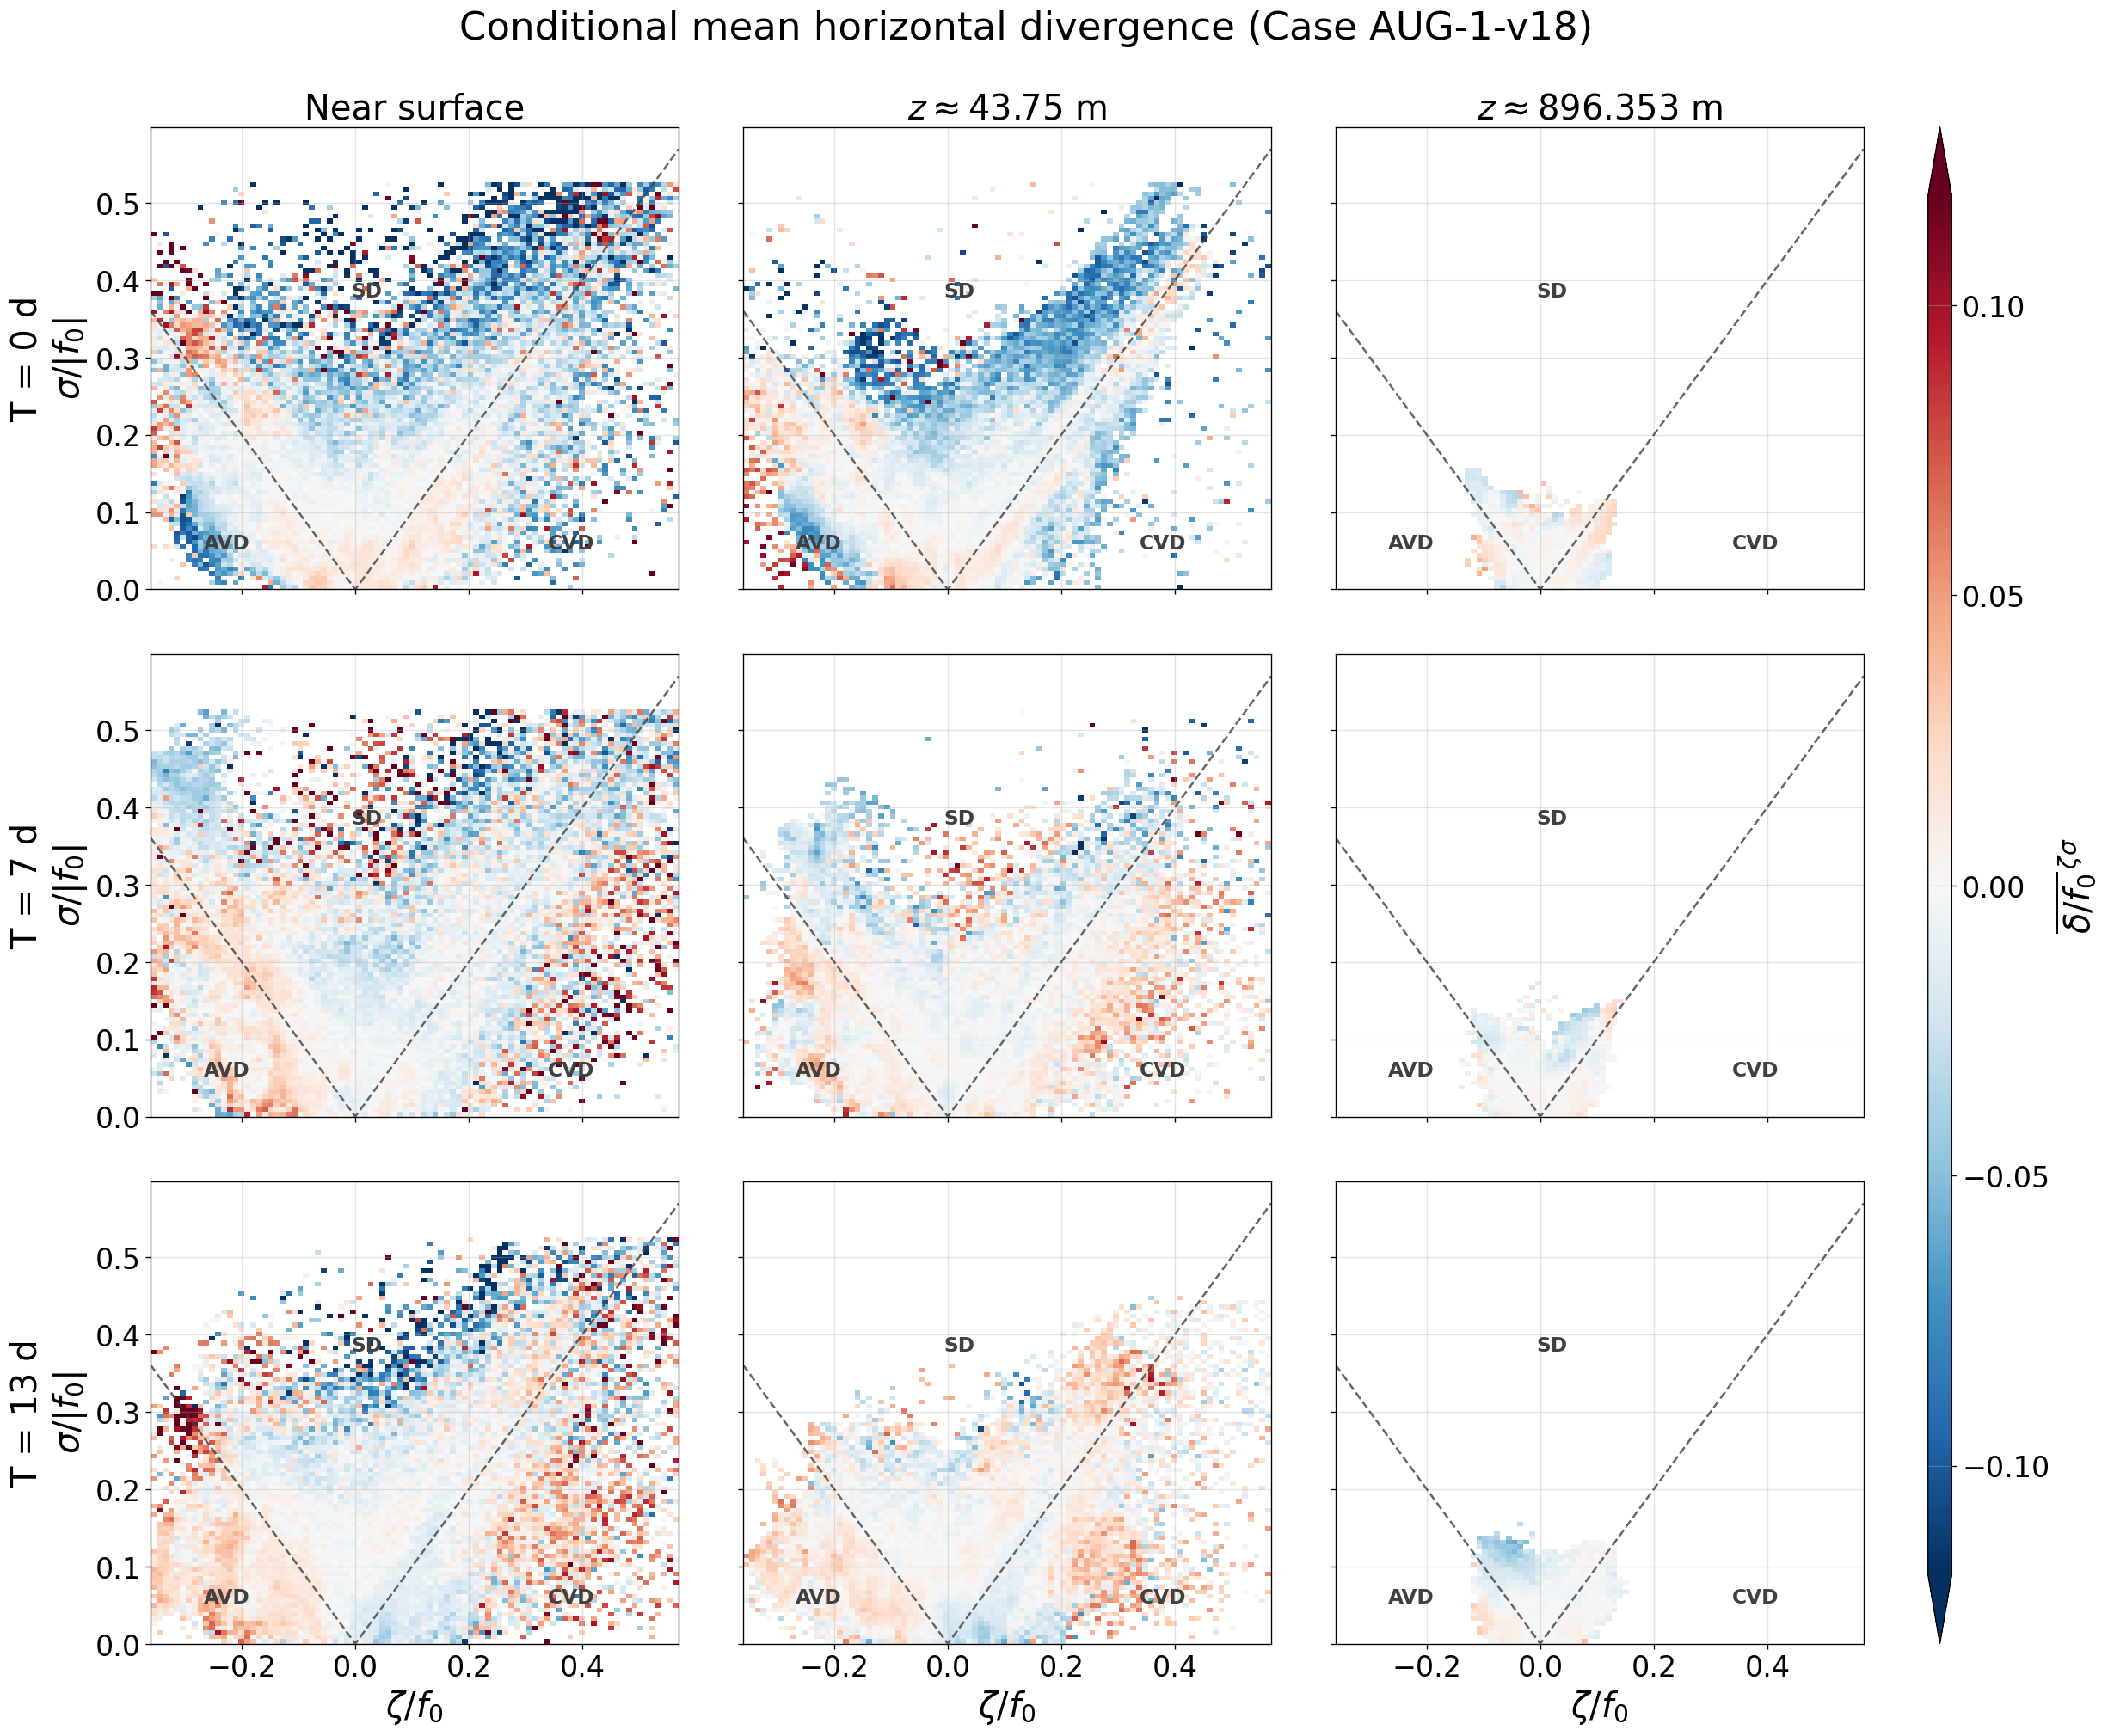


Actual records used for the state rows
  Label T=7 d: state index=3, raw time=1555200 s, actual elapsed=8.27037 d
  Label T=13 d: state index=5, raw time=2073600 s, actual elapsed=14.27037 d


In [24]:
# ------------------------------------------------------------
# FIGURE 2: CONDITIONAL DIVERGENCE AT LABELLED T=0, 7, 13 DAYS
# ------------------------------------------------------------
snapshots = [
    {
        "ds": ds_spin,
        "time_dim": time_spin,
        "z_dim": z_spin,
        "uv_indices": uv_indices_spin,
        "it": it_spin,
        "plot_day": 0.0,
        "actual_day": 0.0,
        "source": "spin-up",
    }
]

for target, (it, actual_day, _) in zip(STATE_TARGET_DAYS, state_selection):
    snapshots.append({
        "ds": ds_state,
        "time_dim": time_state,
        "z_dim": z_state,
        "uv_indices": uv_indices_state,
        "it": it,
        "plot_day": target,
        "actual_day": actual_day,
        "source": "state",
    })

raw_d = []
for snapshot in snapshots:
    for col, kuv in enumerate(snapshot["uv_indices"]):
        ro, div_f, strain = compute_kinematics(
            snapshot["ds"], snapshot["time_dim"], snapshot["z_dim"],
            snapshot["it"], kuv,
        )
        raw_d.append((ro, strain, div_f, snapshot["plot_day"], snapshot["actual_day"], col))

ro_edges_d, strain_edges_d = common_edges([(ro, strain, div) for ro, strain, div, *_ in raw_d])
D_cond = [
    conditioned_mean(ro, strain, div, ro_edges_d, strain_edges_d)
    for ro, strain, div, *_ in raw_d
]
d_limit = shared_symmetric_limit(D_cond)

fig = plt.figure(figsize=(19.5, 17.5), facecolor="white")
gs = fig.add_gridspec(
    3, 4, width_ratios=[1, 1, 1, 0.045],
    left=0.065, right=0.96, bottom=0.07, top=0.91,
    wspace=0.16, hspace=0.14,
)
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(3)])
cax = fig.add_subplot(gs[:, 3])

for index, (field, (_, _, _, plot_day, actual_day, col)) in enumerate(zip(D_cond, raw_d)):
    row = index // 3
    ax = axes[row, col]
    if row == 0:
        selected_depth = uv_depths_spin[uv_indices_spin[col]]
        title = (
            "Near surface"
            if col == 0
            else rf"$z \approx {selected_depth:g}\ \mathrm{{m}}$"
        )
    else:
        title = ""
    pcm = draw_panel(ax, field, ro_edges_d, strain_edges_d, d_limit, title=title)

    if row == 2:
        ax.set_xlabel(r"$\zeta/f_0$")
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(rf"T = {plot_day:g} d" + "\n" + r"$\sigma/|f_0|$")
    else:
        ax.tick_params(labelleft=False)

cbar = fig.colorbar(pcm, cax=cax, extend="both")
cbar.set_label(r"$\overline{\delta/f_0}^{\,\zeta\sigma}$")
fig.suptitle(f"Conditional mean horizontal divergence ({RUN_TITLE_INFO})", y=0.975)
shu.savefig_if_needed(
    fig, f"conditional_divergence_{case_name}",
    save=SAVE, out_dir=OUT_DIR,
)
plt.show()

print("\nActual records used for the state rows")
for target, (it, actual_day, raw_time_s) in zip(STATE_TARGET_DAYS, state_selection):
    print(
        f"  Label T={target:g} d: state index={it}, "
        f"raw time={raw_time_s:.0f} s, actual elapsed={actual_day:.5f} d"
    )

In [25]:
# # ------------------------------------------------------------
# # USER SETTINGS
# # ------------------------------------------------------------
# CASES = [
#     {"case_name": "run_aug1_v42", "label": "AUG-1-v42"},
#     {"case_name": "run_aug1_v36", "label": "AUG-1-v36"},
# ]

# TARGET_DAYS = [0.0, 7.0, 13.0]

# # same near-surface UV level for all cases
# UV_INDEX = globals().get("NEAR_SURFACE_UV_INDEX", 1)

# # output
# OUT_DIR_CC = (NB_DIR / "../results/cross_case").resolve()
# OUT_DIR_CC.mkdir(parents=True, exist_ok=True)

# # plotting / binning defaults
# NBINS_CC = globals().get("NBINS", 80)
# MIN_BIN_COUNT_CC = globals().get("MIN_BIN_COUNT", 10)
# PERCENTILE_LIMIT_CC = globals().get("PERCENTILE_LIMIT", 99.0)

# # ------------------------------------------------------------
# # HELPERS
# # ------------------------------------------------------------
# def open_case_cc(path):
#     ds = xr.open_dataset(path, chunks="auto")
#     time_dim = shu.find_dim(ds.dims, ["T", "time", "iter"])
#     z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
#     return ds, time_dim, z_dim


# def time_seconds_cc(ds, time_dim):
#     vals = np.asarray(ds[time_dim].values)

#     if np.issubdtype(vals.dtype, np.timedelta64):
#         return np.asarray(vals / np.timedelta64(1, "s"), dtype=float)

#     if np.issubdtype(vals.dtype, np.datetime64):
#         return np.asarray((vals - vals[0]) / np.timedelta64(1, "s"), dtype=float)

#     vals = vals.astype(float)
#     units = str(ds[time_dim].attrs.get("units", "")).lower()

#     if "day" in units:
#         return vals * 86400.0
#     if "hour" in units:
#         return vals * 3600.0
#     if "second" in units or units.strip() == "s":
#         return vals

#     # fallback: your files store model time in seconds
#     return vals


# def usable_uv_record_cc(ds, time_dim, z_dim, it, k):
#     """Check whether a record contains usable U/V data at one UV level."""
#     u = shu.clean_fill(ds["UVEL"].isel({time_dim: it, z_dim: k}).values)
#     v = shu.clean_fill(ds["VVEL"].isel({time_dim: it, z_dim: k}).values)

#     valid_u = np.isfinite(u)
#     valid_v = np.isfinite(v)

#     if valid_u.mean() < 0.1 or valid_v.mean() < 0.1:
#         return False
#     if not valid_u.any() or not valid_v.any():
#         return False

#     u_std = np.nanstd(u[valid_u])
#     v_std = np.nanstd(v[valid_v])

#     if (
#         not np.isfinite(u_std)
#         or not np.isfinite(v_std)
#         or (u_std <= 1.0e-14 and v_std <= 1.0e-14)
#     ):
#         return False

#     return True


# def select_spinup_record_cc(ds, time_dim, z_dim, k):
#     valid = [
#         it for it in range(ds.sizes[time_dim])
#         if usable_uv_record_cc(ds, time_dim, z_dim, it, k)
#     ]
#     if not valid:
#         raise ValueError("No usable record found in spinup file.")
#     return valid[0]


# def select_state_record_cc(ds, time_dim, z_dim, k, spinup_time_s, target_day):
#     times_s = time_seconds_cc(ds, time_dim)

#     valid = [
#         it for it in range(ds.sizes[time_dim])
#         if usable_uv_record_cc(ds, time_dim, z_dim, it, k)
#     ]
#     if not valid:
#         raise ValueError("No usable record found in state file.")

#     elapsed_days = np.array([(times_s[it] - spinup_time_s) / 86400.0 for it in valid])
#     idx = int(np.argmin(np.abs(elapsed_days - target_day)))
#     it = int(valid[idx])

#     return it, float(elapsed_days[idx]), float(times_s[it])


# def compute_kinematics_cc(ds, time_dim, z_dim, it, k):
#     with warnings.catch_warnings():
#         warnings.filterwarnings(
#             "ignore",
#             message="Mean of empty slice",
#             category=RuntimeWarning,
#         )
#         ro, div_f, strain_f = shu.compute_surface_kinematics(
#             ds,
#             time_dim,
#             z_dim,
#             it,
#             [k],
#             DX,
#             DY,
#             F0,
#         )

#     return ro, div_f, strain_f


# def common_edges_cc(fields):
#     """
#     Use wider common axes for all 9 panels.
#     This mainly helps the FEB case by allowing a larger shared
#     vorticity-strain range.
#     """
#     ro_all = np.concatenate([ro[np.isfinite(ro)] for ro, _, _ in fields])
#     st_all = np.concatenate([st[np.isfinite(st)] for _, st, _ in fields])

#     # Wider percentiles than before
#     x0, x1 = np.nanpercentile(ro_all, [0.02, 99.98])
#     y0, y1 = np.nanpercentile(st_all, [0.02, 99.98])

#     xpad = 0.06 * (x1 - x0)
#     ypad = 0.06 * (y1 - y0)

#     return (
#         np.linspace(x0 - xpad, x1 + xpad, NBINS_CC + 1),
#         np.linspace(max(0.0, y0 - ypad), y1 + ypad, NBINS_CC + 1),
#     )

# def conditioned_mean_cc(ro, strain, value, ro_edges, strain_edges):
#     value, ro, strain = shu.crop_to_common_shape(value, ro, strain)
#     mask = np.isfinite(value) & np.isfinite(ro) & np.isfinite(strain)

#     mean, count = shu.conditioned_mean_2d(
#         ro[mask],
#         strain[mask],
#         value[mask],
#         ro_edges,
#         strain_edges,
#     )
#     mean = np.asarray(mean, dtype=float)
#     mean[count < MIN_BIN_COUNT_CC] = np.nan
#     return mean


# def draw_panel_cc(ax, field, x_edges, y_edges, limit, title=""):
#     pcm = ax.pcolormesh(
#         x_edges,
#         y_edges,
#         field.T,
#         shading="auto",
#         cmap=shu.get_cmap("conditional"),
#         vmin=-limit,
#         vmax=limit,
#     )

#     xx = np.linspace(x_edges[0], x_edges[-1], 500)
#     ax.plot(
#         xx,
#         np.abs(xx),
#         "--",
#         color=shu.get_color("reference"),
#         lw=1.5,
#         alpha=0.8,
#     )

#     shu.add_regime_labels(ax, x_edges, y_edges)
#     shu.format_axis(ax, title=title, grid=True, equal=False)
#     return pcm


# # ------------------------------------------------------------
# # CASE LOADING + SNAPSHOT SELECTION
# # ------------------------------------------------------------
# records = []
# selection_log = []

# for col, case in enumerate(CASES):
#     case_name = case["case_name"]
#     case_label = case["label"]

#     state_file = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
#     spinup_file = state_file.with_name(f"{state_file.stem}_spinup{state_file.suffix}")

#     if not state_file.exists():
#         raise FileNotFoundError(state_file)
#     if not spinup_file.exists():
#         raise FileNotFoundError(spinup_file)

#     # spinup file for T=0 and time reference
#     ds_spin, time_spin, z_spin = open_case_cc(spinup_file)
#     it_spin = select_spinup_record_cc(ds_spin, time_spin, z_spin, UV_INDEX)
#     spinup_time_s = float(time_seconds_cc(ds_spin, time_spin)[it_spin])

#     # state file for later times
#     ds_state, time_state, z_state = open_case_cc(state_file)

#     for row, target_day in enumerate(TARGET_DAYS):
#         if np.isclose(target_day, 0.0):
#             ds_use = ds_spin
#             time_dim_use = time_spin
#             z_dim_use = z_spin
#             it_use = it_spin
#             actual_day = 0.0
#             raw_time_s = spinup_time_s
#             source = "spinup"
#         else:
#             it_use, actual_day, raw_time_s = select_state_record_cc(
#                 ds_state,
#                 time_state,
#                 z_state,
#                 UV_INDEX,
#                 spinup_time_s,
#                 target_day,
#             )
#             ds_use = ds_state
#             time_dim_use = time_state
#             z_dim_use = z_state
#             source = "state"

#         ro, div_f, strain = compute_kinematics_cc(
#             ds_use,
#             time_dim_use,
#             z_dim_use,
#             it_use,
#             UV_INDEX,
#         )

#         records.append({
#             "row": row,
#             "col": col,
#             "case_label": case_label,
#             "target_day": target_day,
#             "actual_day": actual_day,
#             "source": source,
#             "ro": ro,
#             "strain": strain,
#             "div": div_f,
#         })

#         selection_log.append({
#             "case_label": case_label,
#             "target_day": target_day,
#             "actual_day": actual_day,
#             "index": int(it_use),
#             "raw_time_s": raw_time_s,
#             "source": source,
#         })


# # ------------------------------------------------------------
# # CASE-SPECIFIC BINS / COMMON COLOR LIMIT
# # rows = cases, columns = snapshots
# # ------------------------------------------------------------

# # Separate vorticity-strain bins for each case.
# # All three snapshots of one case retain identical axes.
# case_edges_cc = {}

# for case_idx, case in enumerate(CASES):
#     case_fields = [
#         (rec["ro"], rec["strain"], rec["div"])
#         for rec in records
#         if rec["col"] == case_idx
#     ]

#     case_edges_cc[case_idx] = common_edges_cc(case_fields)


# # Calculate conditional divergence using each case's own bins.
# D_cond_cc = []

# for rec in records:
#     case_idx = rec["col"]
#     ro_edges_case, strain_edges_case = case_edges_cc[case_idx]

#     field = conditioned_mean_cc(
#         rec["ro"],
#         rec["strain"],
#         rec["div"],
#         ro_edges_case,
#         strain_edges_case,
#     )

#     D_cond_cc.append(field)


# # One common divergence colour scale across all cases and snapshots.
# finite_divergence = [
#     np.abs(field[np.isfinite(field)])
#     for field in D_cond_cc
#     if np.any(np.isfinite(field))
# ]

# if finite_divergence:
#     dlim_cc = float(
#         np.nanpercentile(
#             np.concatenate(finite_divergence),
#             98.5,
#         )
#     )
# else:
#     dlim_cc = 1.0

# if not np.isfinite(dlim_cc) or dlim_cc == 0:
#     dlim_cc = 1.0


# # ------------------------------------------------------------
# # PLOT
# # rows = cases, columns = T=0 / T=7 / T=13
# # ------------------------------------------------------------
# plt.rcParams.update({
#     "font.size": 20,
#     "axes.titlesize": 24,
#     "axes.labelsize": 24,
#     "xtick.labelsize": 19,
#     "ytick.labelsize": 19,
#     "figure.titlesize": 30,
#     "savefig.dpi": 300,
# })

# fig, axes = plt.subplots(
#     len(CASES),
#     len(TARGET_DAYS),
#     figsize=(22, 19),
#     sharex=False,
#     sharey=False,
#     facecolor="white",
#     constrained_layout=False,
# )

# fig.subplots_adjust(
#     left=0.085,
#     right=0.90,
#     bottom=0.075,
#     top=0.91,
#     wspace=0.13,
#     hspace=0.16,
# )


# for rec, field in zip(records, D_cond_cc):
#     # Original records:
#     # rec["row"] = snapshot index
#     # rec["col"] = case index
#     #
#     # Plot layout:
#     # plot row    = case
#     # plot column = snapshot
#     plot_row = rec["col"]
#     plot_col = rec["row"]

#     ax = axes[plot_row, plot_col]

#     ro_edges_case, strain_edges_case = case_edges_cc[plot_row]

#     pcm = draw_panel_cc(
#         ax,
#         field,
#         ro_edges_case,
#         strain_edges_case,
#         dlim_cc,
#         title="",
#     )

#     # Identical axes for all snapshots of the same case.
#     ax.set_xlim(
#         ro_edges_case[0],
#         ro_edges_case[-1],
#     )
#     ax.set_ylim(
#         strain_edges_case[0],
#         strain_edges_case[-1],
#     )

#     # Column titles represent requested snapshots.
#     if plot_row == 0:
#         ax.set_title(
#             rf"$T={TARGET_DAYS[plot_col]:g}\ \mathrm{{d}}$"
#         )

#     # Case names appear on the left of each row.
#     if plot_col == 0:
#         ax.set_ylabel(
#             rec["case_label"]
#             + "\n"
#             + r"$\sigma/|f_0|$"
#         )
#     else:
#         ax.tick_params(labelleft=False)

#     # Keep numerical x ticks visible because each case row
#     # may have a different vorticity range.
#     if plot_row == len(CASES) - 1:
#         ax.set_xlabel(r"$\zeta/f_0$")

#     ax.tick_params(
#         axis="both",
#         which="major",
#         labelsize=19,
#         length=7,
#         width=1.3,
#     )

#     for text in ax.texts:
#         if text.get_text() in {"AVD", "SD", "CVD"}:
#             text.set_fontsize(19)
#             text.set_fontweight("bold")


# # Shared divergence colorbar.
# cax = fig.add_axes([
#     0.915,
#     0.135,
#     0.018,
#     0.73,
# ])

# cbar = fig.colorbar(
#     pcm,
#     cax=cax,
#     extend="both",
# )

# cbar.set_label(
#     r"$\overline{\delta/f_0}^{\,\zeta\sigma}$",
#     fontsize=24,
#     labelpad=18,
# )

# cbar.ax.tick_params(
#     labelsize=19,
#     length=7,
#     width=1.3,
# )


# fig.suptitle(
#     r"Conditional mean horizontal divergence "
#     r"($z/\mathrm{MLD}\approx 0$)",
#     fontsize=30,
#     y=0.97,
# )


# plt.show()

# # ------------------------------------------------------------
# # PRINT ACTUAL SNAPSHOTS USED
# # ------------------------------------------------------------
# print("\nSelected snapshots used:")
# for item in selection_log:
#     print(
#         f"{item['case_label']:>8s} | "
#         f"requested T={item['target_day']:>4.0f} d | "
#         f"actual T={item['actual_day']:>8.5f} d | "
#         f"index={item['index']:>3d} | "
#         f"raw time={item['raw_time_s']:.0f} s | "
#         f"source={item['source']}"
#     )